# IMAGE GENERATION FROM BRAIN ACTIVITY
## EDA. Исследование данных

Данные подготовлены для subject-1

In [10]:
# установка библиотек
!pip install umap-learn > None
!pip install cupy > None
!pip install -U kaleido > None

In [11]:
# Работа в Coogle Colaboratory
# import os
# from google.colab import drive

# drive.mount('/content/drive')
# path = 'drive/MyDrive/Colab Notebooks'

# os.chdir(path)

In [12]:
# импорт библиотек
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2

import cupy as cp
import torch
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
from umap import UMAP

seed = 42
sns.set_theme()

2024-06-30 20:54:59.110846: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-30 20:54:59.110983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-30 20:54:59.276637: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Чтение данных

In [8]:
path = '/kaggle/input/NaturalScenesDataset_preproc'

# train_caption = np.load(path + '/train/captions.npy', mmap_mode='r')
train_voxels = np.load(path + '/train/voxels.npy', mmap_mode='r')
train_images = np.load(path + '/train/images.npy', mmap_mode='r')
train_caption_emb = np.load(path + '/train/caption_embs.npy', mmap_mode="r")

val_caption = np.load(path + '/val/captions.npy', mmap_mode='r')
val_voxels = np.load(path + '/val/voxels.npy', mmap_mode='r')
val_images = np.load(path + '/val/images.npy', mmap_mode='r')
val_caption_emb = np.load(path + '/val/caption_embs.npy', mmap_mode="r")

test_caption = np.load(path + '/test/captions.npy', mmap_mode='r')
test_voxels = np.load(path + '/test/voxels.npy', mmap_mode='r')
test_images = np.load(path + '/test/images.npy', mmap_mode='r')
test_caption_emb = np.load(path + '/test/caption_embs.npy', mmap_mode="r")

### Анализ данных

In [5]:
train_coco_indexes = np.load(path + '/train/coco_indexes.npy', mmap_mode="r")

In [6]:
np.where(train_coco_indexes == 3220)

(array([89]),)

In [ ]:
plt.axis('off')
plt.imshow(torch.Tensor(train_images[89]/255).permute(1, 2, 0))
plt.savefig('foo.png')

In [8]:
train_caption[89]

'A child sitting on a bench in the grass near a building with a red door. A girl sits on a bench on grass outside a red door'

#### Данные вокселей

In [9]:
train_voxels.shape

(8700, 15724)

In [ ]:
fig = plt.figure(figsize=(15, 6))
plt.plot(train_voxels.mean(axis=0))
plt.xlabel('Component index')
plt.ylabel('Component mean value')
plt.title('Mean value by components of voxels')
fig.savefig("Mean_by_components_of_voxels.png") 

In [ ]:
fig = plt.figure(figsize=(15, 6))
plt.plot(train_voxels.var(axis=0))
plt.xlabel('Component index')
plt.ylabel('Component variance value')
plt.title('Variance by components of voxels')
fig.savefig("Variance_by_components_of_voxels.png") 

In [37]:
cupy_items = cp.array(train_voxels)
pearson = cp.corrcoef(cupy_items.T)
indexes = np.where((pearson > 0.7) | (pearson < -0.7))

In [ ]:
fig = plt.figure(figsize=(12, 10))
sns.heatmap(pearson.get(), annot=False)
plt.title('Pearson correlation heatmap')
fig.savefig("pearson_corr.png") 

In [38]:
components_corr = {}
corr_pair_indexes = []

for elem_i, elem_j in zip(indexes[0].get(), indexes[1].get()):
    if elem_i != elem_j:
        if elem_i not in components_corr.keys():
            components_corr[elem_i] = []
        if elem_j not in components_corr.keys():
            components_corr[elem_j] = []
        if elem_j not in components_corr[elem_i] and elem_i not in components_corr[elem_j]:
            components_corr[elem_i].append(elem_j)
            components_corr[elem_j].append(elem_i)
            corr_pair_indexes.append([elem_i, elem_j])    
corr_pair_indexes = np.array(corr_pair_indexes)

In [40]:
subpearson = pearson[corr_pair_indexes[:, 0], corr_pair_indexes[:, 1]]
len(subpearson)

45740

In [41]:
corr_pair_indexes.shape

(45740, 2)

1. Высокая размерность пространства вокселей. Больше требований к размеру обучающей выборки.
2. 45740 случаев наличия корреляция по Пирсону между вокселями

#### Данные caption embeddings

In [17]:
train_caption_emb.shape

(8700, 1280)

In [ ]:
fig = plt.figure(figsize=(15, 6))
plt.plot(train_caption_emb.mean(axis=0))
plt.title('Mean by components of caption embeddings')
fig.savefig("Mean by components of cap_embs.png") 

In [ ]:
fig = plt.figure(figsize=(15, 6))
plt.plot(train_caption_emb.var(axis=0))
plt.title('Variance by components of caption embeddings')
fig.savefig("Variance_by_components_of_cap_embs.png") 

In [20]:
cupy_items = cp.array(train_caption_emb)
pearson = cp.corrcoef(cupy_items.T)
indexes = np.where((pearson > 0.5) | (pearson < -0.5))

In [ ]:
fig = plt.figure(figsize=(12, 10))
sns.heatmap(pearson.get(), annot=False)
plt.title('Pearson correlation heatmap')
fig.savefig("pearson_corr_cap_embs.png") 

In [22]:
components_corr = {}
corr_pair_indexes = []

for elem_i, elem_j in zip(indexes[0].get(), indexes[1].get()):
    if elem_i != elem_j:
        if elem_i not in components_corr.keys():
            components_corr[elem_i] = []
        if elem_j not in components_corr.keys():
            components_corr[elem_j] = []
        if elem_j not in components_corr[elem_i]:
            components_corr[elem_i].append(elem_j)
            components_corr[elem_j].append(elem_i)
            corr_pair_indexes.append([elem_i, elem_j])    
corr_pair_indexes = np.array(corr_pair_indexes)

In [23]:
subpearson = pearson[corr_pair_indexes[:, 0], corr_pair_indexes[:, 1]]
len(subpearson[subpearson > 0.7])

24

In [24]:
corr_pair_indexes

array([[  11, 1274],
       [  51,  531],
       [  61,  185],
       [  61,  342],
       [  61,  609],
       [  61,  633],
       [  61,  751],
       [  61,  788],
       [  61,  960],
       [  61, 1218],
       [  61, 1262],
       [  62,  531],
       [  76, 1224],
       [ 172,  624],
       [ 172,  992],
       [ 172, 1096],
       [ 172, 1138],
       [ 185,  342],
       [ 185,  609],
       [ 185,  633],
       [ 185,  751],
       [ 185,  788],
       [ 185,  960],
       [ 185, 1218],
       [ 185, 1262],
       [ 208,  241],
       [ 236,  276],
       [ 255,  822],
       [ 276,  887],
       [ 340,  591],
       [ 340, 1274],
       [ 342,  609],
       [ 342,  633],
       [ 342,  751],
       [ 342,  788],
       [ 342,  795],
       [ 342,  960],
       [ 342, 1138],
       [ 342, 1218],
       [ 342, 1262],
       [ 352,  881],
       [ 352, 1068],
       [ 372,  881],
       [ 401, 1234],
       [ 531,  591],
       [ 533,  547],
       [ 542, 1260],
       [ 591,

1. Высокая размерность латентного представления captions. Больше требований к размеру обучающей выборки.
2. 24 случаев наличия корреляция по Пирсону между компонтентами латентного представления captions.

#### Визуализация пространства вокселей

##### Уменьшение размерности до 2d

In [6]:
# уменьшение размерности
train_voxels_2d = UMAP(random_state=seed).fit_transform(train_voxels)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [7]:
train_voxels_2d.shape

(8700, 2)

##### Подбор числа кластеров

In [8]:
# подбор количества кластеров
ks = range(100, 2000, 25)
ssr = []
silhouette = []
db_index = []
ch_index = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=seed, n_init=3)
    model.fit(train_voxels_2d)
      
    ssr.append(model.inertia_)
    silhouette.append(metrics.silhouette_score(train_voxels_2d, model.labels_, metric='euclidean')) # -1 to 1
    db_index.append(metrics.davies_bouldin_score(train_voxels_2d, model.labels_)) # low value is better
    ch_index.append(metrics.calinski_harabasz_score(train_voxels_2d, model.labels_)) # high value is better

In [ ]:
fig, axis = plt.subplots(4, 1, figsize=(15, 25))

df = pd.DataFrame()
df["k-clusters"] = ks
df["SSE"] = ssr
df["Silhouette Coefficient"] = silhouette
df["Davies-Bouldin Index"] = db_index
df["Calinski-Harabasz Index"] = ch_index

axis[0].plot(df["k-clusters"], df["SSE"], marker="o")
axis[1].plot(df["k-clusters"], df["Silhouette Coefficient"], marker="o")
axis[2].plot(df["k-clusters"], df["Davies-Bouldin Index"], marker="o")
axis[3].plot(df["k-clusters"], df["Calinski-Harabasz Index"], marker="o")

axis[0].set_xlabel('k-clusters')
axis[1].set_xlabel('k-clusters')
axis[2].set_xlabel('k-clusters')
axis[3].set_xlabel('k-clusters')

axis[0].set_ylabel('SSE')
axis[1].set_ylabel('Silhouette Coefficient')
axis[2].set_ylabel('Davies-Bouldin Index')
axis[3].set_ylabel('Calinski-Harabasz Index')

plt.title('The elbow method for voxels')
fig.savefig("elbow_voxels_umap.png") 

##### Уменьшение размерности до 100D

In [5]:
# уменьшение размерности
train_voxels_compressed = UMAP(n_components=100, random_state=seed).fit_transform(train_voxels)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [6]:
train_voxels_compressed.shape

(8700, 100)

##### Подбор числа кластеров

In [11]:
# подбор количества кластеров
ks = range(100, 2000, 25)
ssr = []
silhouette = []
db_index = []
ch_index = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=seed, n_init=3)
    model.fit(train_voxels_compressed)
      
    ssr.append(model.inertia_)
    silhouette.append(metrics.silhouette_score(train_voxels_compressed, model.labels_, metric='euclidean')) # -1 to 1
    db_index.append(metrics.davies_bouldin_score(train_voxels_compressed, model.labels_)) # low value is better
    ch_index.append(metrics.calinski_harabasz_score(train_voxels_compressed, model.labels_)) # high value is better

In [ ]:
fig, axis = plt.subplots(4, 1, figsize=(15, 25))

df = pd.DataFrame()
df["k-clusters"] = ks
df["SSE"] = ssr
df["Silhouette Coefficient"] = silhouette
df["Davies-Bouldin Index"] = db_index
df["Calinski-Harabasz Index"] = ch_index

axis[0].plot(df["k-clusters"], df["SSE"], marker="o")
axis[1].plot(df["k-clusters"], df["Silhouette Coefficient"], marker="o")
axis[2].plot(df["k-clusters"], df["Davies-Bouldin Index"], marker="o")
axis[3].plot(df["k-clusters"], df["Calinski-Harabasz Index"], marker="o")

axis[0].set_xlabel('k-clusters')
axis[1].set_xlabel('k-clusters')
axis[2].set_xlabel('k-clusters')
axis[3].set_xlabel('k-clusters')

axis[0].set_ylabel('SSE')
axis[1].set_ylabel('Silhouette Coefficient')
axis[2].set_ylabel('Davies-Bouldin Index')
axis[3].set_ylabel('Calinski-Harabasz Index')

plt.title('The elbow method for voxels')
fig.savefig("elbow_voxels_umap_ndim.png") 

##### Кластеризация

###### 10D

In [4]:
# уменьшение размерности до 10d
train_voxels_10d = UMAP(n_components=10, random_state=seed).fit_transform(train_voxels)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [5]:
# кластеризация в 10d
kmeans_voxels_10d = KMeans(n_clusters=1000, random_state=seed, n_init=3).fit(train_voxels_10d)

In [ ]:
# уменьшение размерности для визуализации
train_voxels_2d = UMAP(n_components=2, random_state=seed).fit_transform(train_voxels)

df = pd.DataFrame()
df["cluster"] = kmeans_voxels_10d.labels_
df["comp-1"] = train_voxels_2d[:,0]
df["comp-2"] = train_voxels_2d[:,1]

fig = px.scatter(df, x="comp-1", y="comp-2", 
                 color="cluster", 
                 width=800, height=800,
                 title='Voxel clusters'
                )
fig.show()
fig.write_image('cluster_voxels_10d.png')

###### 2D

In [ ]:
# уменьшение размерности до 2d
train_voxels_2d = UMAP(n_components=2, random_state=seed).fit_transform(train_voxels)

In [8]:
# кластеризация в 2d
kmeans_voxels_2d = KMeans(n_clusters=1000, random_state=seed, n_init=3).fit(train_voxels_2d)

In [ ]:
df = pd.DataFrame()
df["cluster"] = kmeans_voxels_2d.labels_
df["comp-1"] = train_voxels_2d[:,0]
df["comp-2"] = train_voxels_2d[:,1]

fig = px.scatter(df, x="comp-1", y="comp-2", 
                 color="cluster", 
                 width=800, height=800,
                 title='Voxel clusters'
                )
fig.show()
fig.write_image('cluster_voxels_2d.png')

##### Проверка соответствия

###### 10D

In [ ]:
cluster = 25
test_indexes = np.where(kmeans_voxels_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_10d.png')

In [ ]:
cluster = 10
test_indexes = np.where(kmeans_voxels_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_10d.png')

In [ ]:
cluster = 202
test_indexes = np.where(kmeans_voxels_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_10d.png')

In [ ]:
cluster = 100
test_indexes = np.where(kmeans_voxels_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_10d.png')

In [ ]:
cluster = 105
test_indexes = np.where(kmeans_voxels_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_10d.png')

In [ ]:
cluster = 710
test_indexes = np.where(kmeans_voxels_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_10d.png')

###### 2D

In [ ]:
cluster = 25
test_indexes = np.where(kmeans_voxels_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_2d.png')

In [ ]:
cluster = 10
test_indexes = np.where(kmeans_voxels_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_2d.png')

In [ ]:
cluster = 202
test_indexes = np.where(kmeans_voxels_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_2d.png')

In [ ]:
cluster = 100
test_indexes = np.where(kmeans_voxels_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_2d.png')

In [ ]:
cluster = 172
test_indexes = np.where(kmeans_voxels_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_2d.png')

In [ ]:
cluster = 217
test_indexes = np.where(kmeans_voxels_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'voxel_cluster({cluster})_samples_2d.png')

**Замечания:** \
Были испытаны алгоритмы SVD и PCA для уменьшения размерности. Для SVD нужно более точно отбирать информативные компоненты. PCA чувствителен к размерности и долго работает, однако, новые компоненты интерпретируемы.

**Вывод:**
1. Выполнена кластеризация в 2D и 100D пространствах. Для обоих случаев оптимальное число кластеров находится в диапазоне от 750 до 1000;
2. Выбрано максимальное число кластеров, равное 1000. Это позволит выделять более однородные кластеры, но в то же время увеличит число мусорных кластеров.
3. Проведена кластеризация в 100D. Проверка соответствия показала плохие результаты однородности кластеров. Скорее всего это связано с высокой размерностью для евклидовой метрики. Снижено до 10.
4. Проведена кластеризация в 2D и 10D. Облака точек были изображены на двумерном графике. Для 2D и 10D заметно расхождения в метках кластеров. Это связано с тем, что при уменьшении размерности теряется информация.
3. При проверке соответствия изображений в кластерах в 2D и 10D получены одинаково плохие результаты.


**Анализ:** \
Плохая кластеризация может быть обоснована несколькими причинами:
1. Данные мозга трудно подаются кластеризации. Однако, авторы статьи отмечали наличие кластеров в данных активности мозга
2. Уменьшение размерности сильно влияет на качество кластеров. Однако, для 2D, 10D и 100D результаты одинаково плохие.
3. Плохо отобраны данные ROI. В таком случае, есть идея работать с сырыми данными.

### Визуализация пространства caption embeddings

##### Уменьшение размерности до 2D

In [15]:
# уменьшение размерности
train_caption_emb_2d = UMAP(random_state=seed).fit_transform(train_caption_emb)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [16]:
train_caption_emb_2d.shape

(8700, 2)

##### Подбор числа кластеров

In [17]:
# подбор количества кластеров
ks = range(100, 2000, 25)
ssr = []
silhouette = []
db_index = []
ch_index = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=seed, n_init=3)
    model.fit(train_caption_emb_2d)
      
    ssr.append(model.inertia_)
    silhouette.append(metrics.silhouette_score(train_caption_emb_2d, model.labels_, metric='euclidean')) # -1 to 1
    db_index.append(metrics.davies_bouldin_score(train_caption_emb_2d, model.labels_)) # low value is better
    ch_index.append(metrics.calinski_harabasz_score(train_caption_emb_2d, model.labels_)) # high value is better

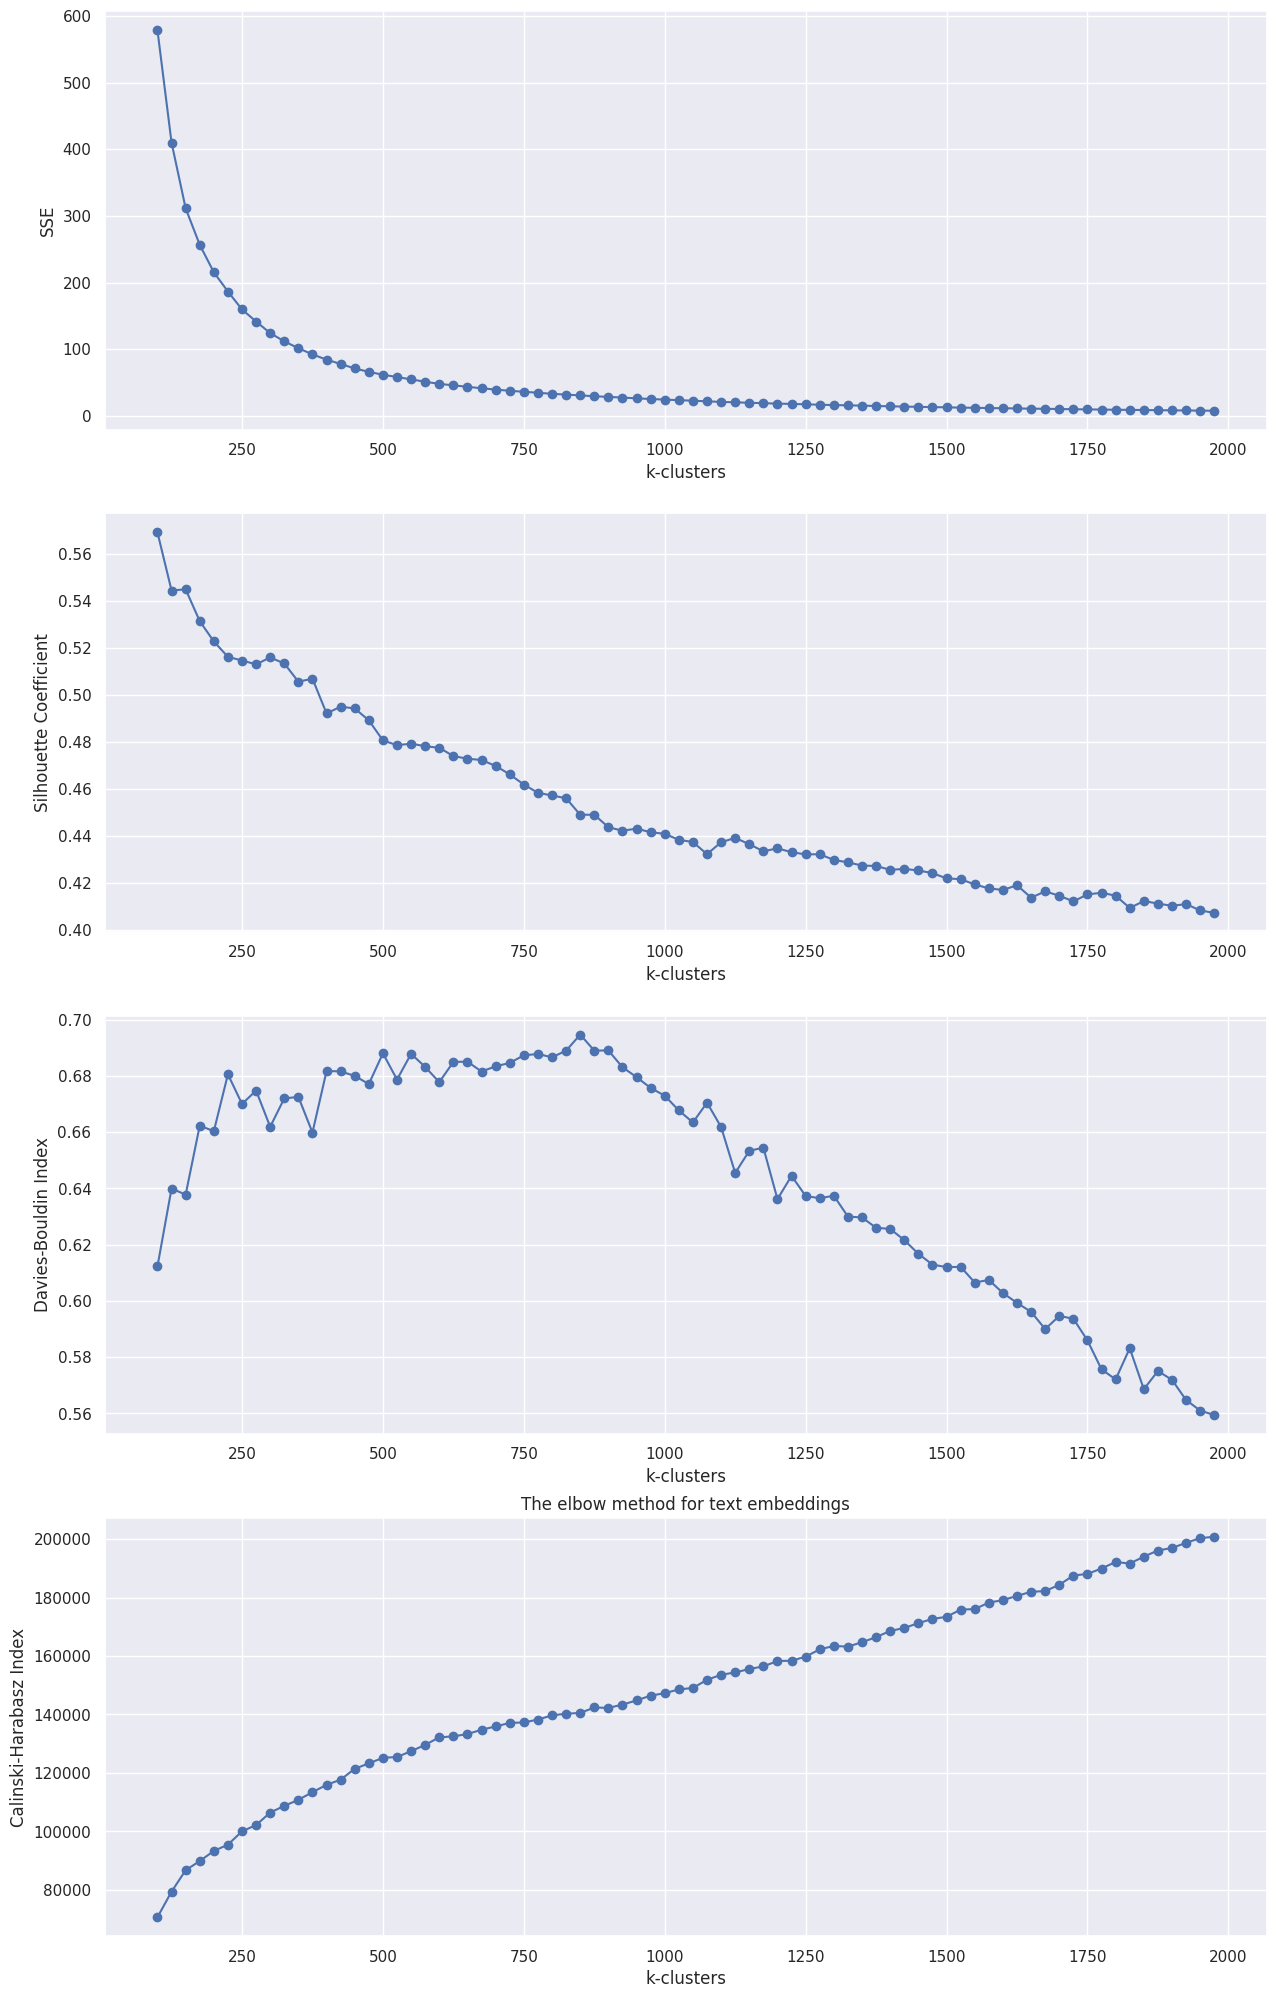

In [18]:
fig, axis = plt.subplots(4, 1, figsize=(15, 25))

df = pd.DataFrame()
df["k-clusters"] = ks
df["SSE"] = ssr
df["Silhouette Coefficient"] = silhouette
df["Davies-Bouldin Index"] = db_index
df["Calinski-Harabasz Index"] = ch_index

axis[0].plot(df["k-clusters"], df["SSE"], marker="o")
axis[1].plot(df["k-clusters"], df["Silhouette Coefficient"], marker="o")
axis[2].plot(df["k-clusters"], df["Davies-Bouldin Index"], marker="o")
axis[3].plot(df["k-clusters"], df["Calinski-Harabasz Index"], marker="o")

axis[0].set_xlabel('k-clusters')
axis[1].set_xlabel('k-clusters')
axis[2].set_xlabel('k-clusters')
axis[3].set_xlabel('k-clusters')

axis[0].set_ylabel('SSE')
axis[1].set_ylabel('Silhouette Coefficient')
axis[2].set_ylabel('Davies-Bouldin Index')
axis[3].set_ylabel('Calinski-Harabasz Index')

plt.title('The elbow method for text embeddings')
fig.savefig("elbow_text_emb_umap.png") 

##### Уменьшение размерности до 100D

In [20]:
# уменьшение размерности
train_caption_emb_compressed = UMAP(n_components=100, random_state=seed).fit_transform(train_caption_emb)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [21]:
train_caption_emb_compressed.shape

(8700, 100)

##### Подбор числа кластеров

In [23]:
# подбор количества кластеров
ks = range(100, 2000, 25)
ssr = []
silhouette = []
db_index = []
ch_index = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=seed, n_init=3)
    model.fit(train_caption_emb_compressed)
      
    ssr.append(model.inertia_)
    silhouette.append(metrics.silhouette_score(train_caption_emb_compressed, model.labels_, metric='euclidean')) # -1 to 1
    db_index.append(metrics.davies_bouldin_score(train_caption_emb_compressed, model.labels_)) # low value is better
    ch_index.append(metrics.calinski_harabasz_score(train_caption_emb_compressed, model.labels_)) # high value is better

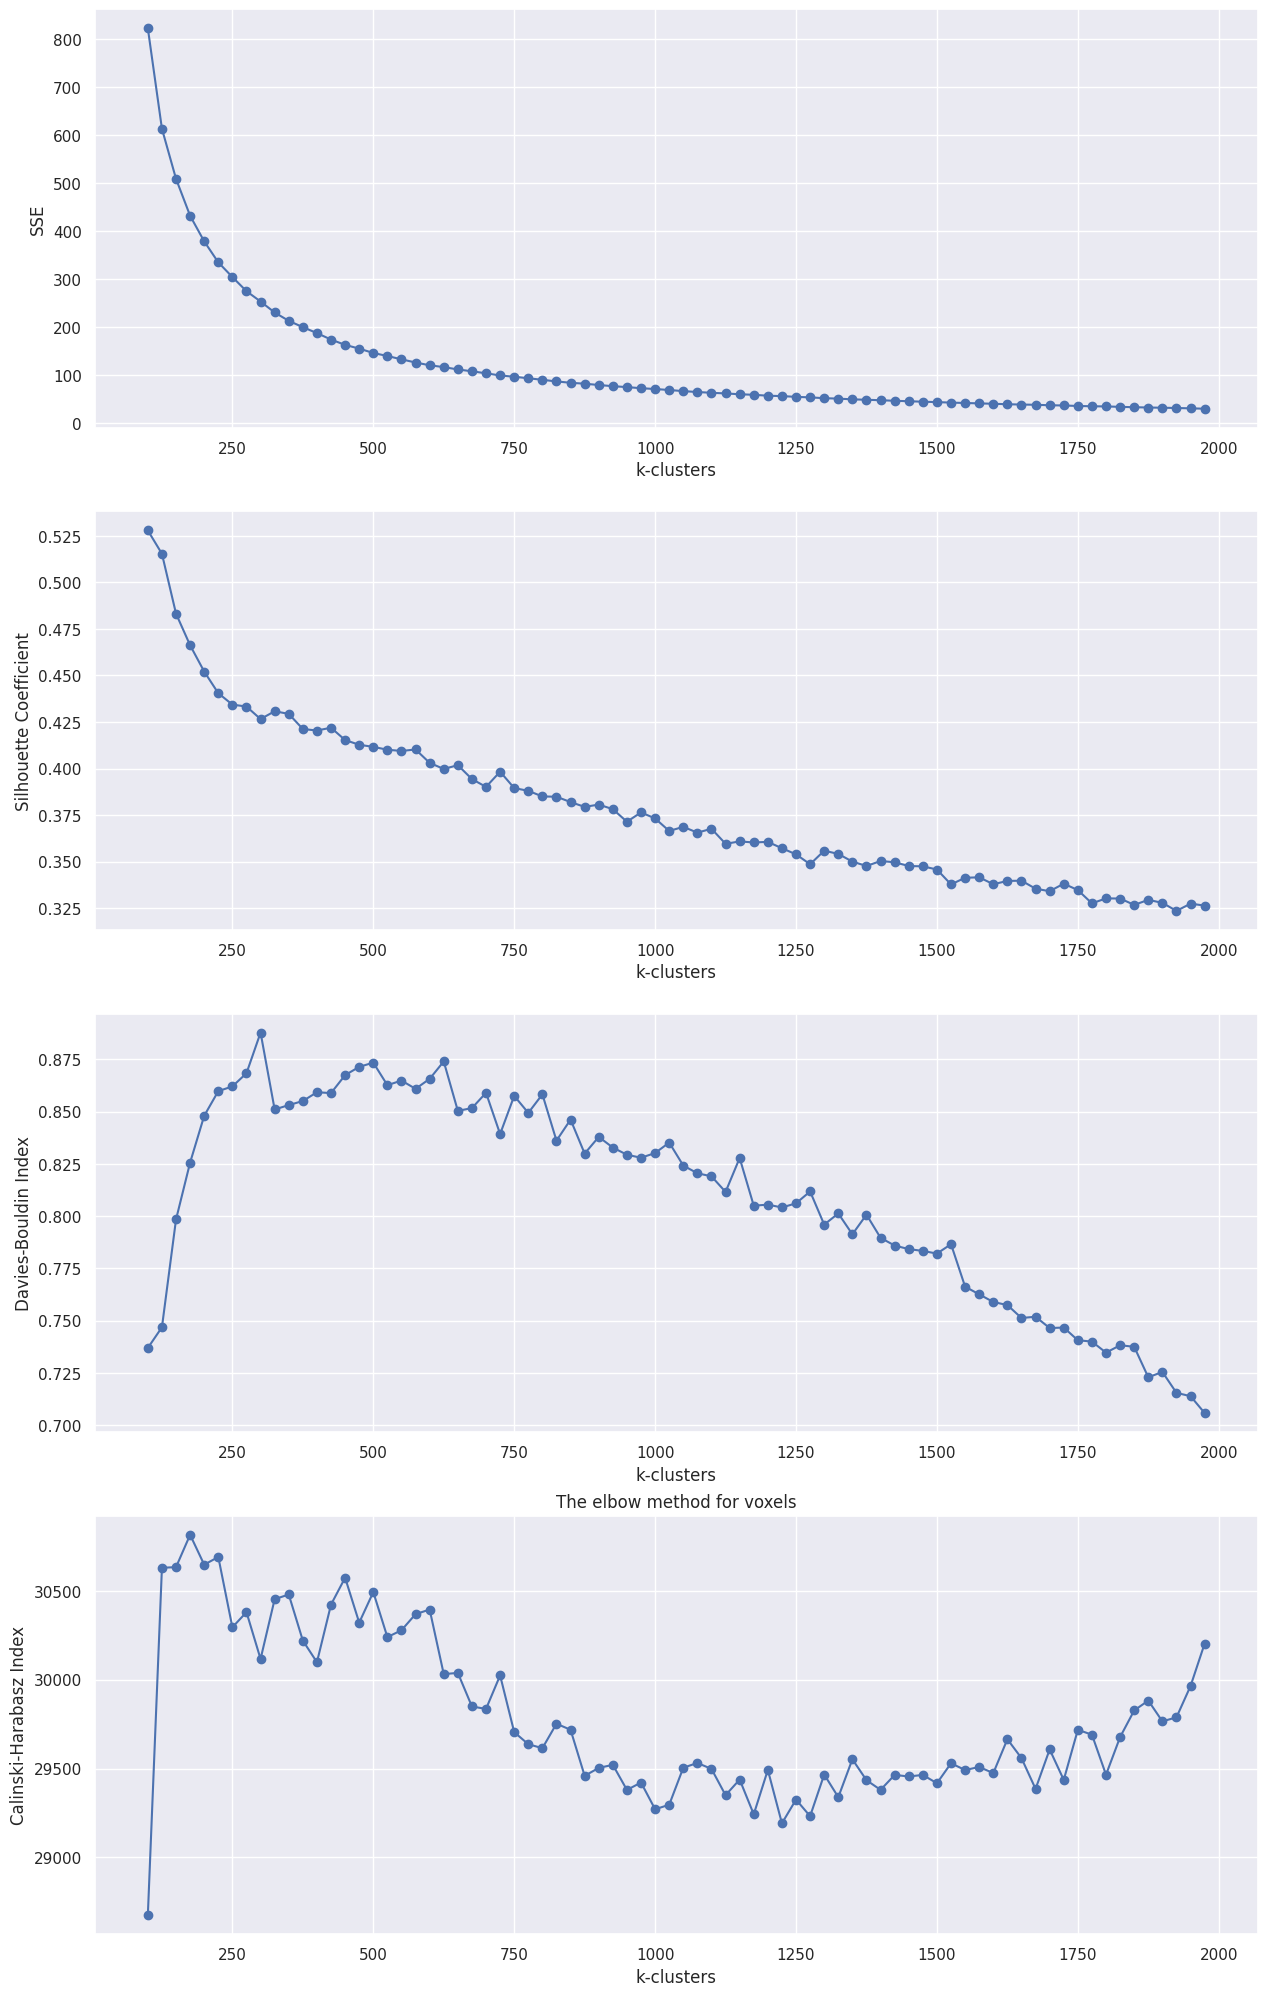

In [24]:
fig, axis = plt.subplots(4, 1, figsize=(15, 25))

df = pd.DataFrame()
df["k-clusters"] = ks
df["SSE"] = ssr
df["Silhouette Coefficient"] = silhouette
df["Davies-Bouldin Index"] = db_index
df["Calinski-Harabasz Index"] = ch_index

axis[0].plot(df["k-clusters"], df["SSE"], marker="o")
axis[1].plot(df["k-clusters"], df["Silhouette Coefficient"], marker="o")
axis[2].plot(df["k-clusters"], df["Davies-Bouldin Index"], marker="o")
axis[3].plot(df["k-clusters"], df["Calinski-Harabasz Index"], marker="o")

axis[0].set_xlabel('k-clusters')
axis[1].set_xlabel('k-clusters')
axis[2].set_xlabel('k-clusters')
axis[3].set_xlabel('k-clusters')

axis[0].set_ylabel('SSE')
axis[1].set_ylabel('Silhouette Coefficient')
axis[2].set_ylabel('Davies-Bouldin Index')
axis[3].set_ylabel('Calinski-Harabasz Index')

plt.title('The elbow method for voxels')
fig.savefig("elbow_text_emb_umap_ndim.png") 

##### Кластеризация

###### 10D

In [47]:
# уменьшение размерности до 10d
train_caption_emb_10d = UMAP(n_components=10, random_state=seed).fit_transform(train_caption_emb)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [48]:
# кластеризация в 10d
kmeans_text_emb_10d = KMeans(n_clusters=750, random_state=seed, n_init=3).fit(train_caption_emb_10d)

In [49]:
# уменьшение размерности для визуализации
train_caption_emb_2d = UMAP(n_components=2, random_state=seed).fit_transform(train_caption_emb)

df = pd.DataFrame()
df["cluster"] = kmeans_text_emb_10d.labels_
df["comp-1"] = train_caption_emb_2d[:,0]
df["comp-2"] = train_caption_emb_2d[:,1]

fig = px.scatter(df, x="comp-1", y="comp-2", 
                 color="cluster", 
                 width=800, height=800,
                 title='Text embedding clusters'
                )
fig.show()
fig.write_image('cluster_text_emb_10d.png')

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



###### 2D

In [50]:
# уменьшение размерности до 10d
train_caption_emb_2d = UMAP(n_components=2, random_state=seed).fit_transform(train_caption_emb)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [51]:
# кластеризация в 2d
kmeans_text_emb_2d = KMeans(n_clusters=750, random_state=seed, n_init=3).fit(train_caption_emb_2d)

In [52]:
df = pd.DataFrame()
df["cluster"] = kmeans_text_emb_2d.labels_
df["comp-1"] = train_caption_emb_2d[:,0]
df["comp-2"] = train_caption_emb_2d[:,1]

fig = px.scatter(df, x="comp-1", y="comp-2", 
                 color="cluster", 
                 width=800, height=800,
                 title='Text embedding clusters'
                )
fig.show()
fig.write_image('cluster_text_emb_2d.png')

##### Проверка соответствия

###### 10D

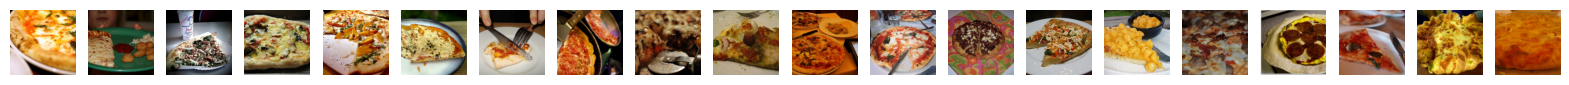

In [64]:
cluster = 25
test_indexes = np.where(kmeans_text_emb_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_10d.png')

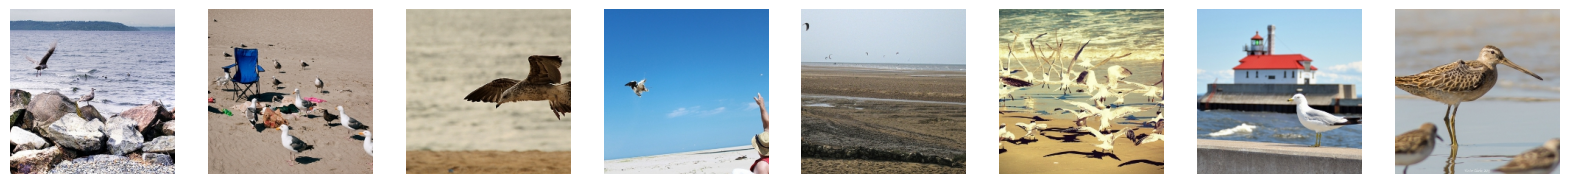

In [65]:
cluster = 100
test_indexes = np.where(kmeans_text_emb_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_10d.png')

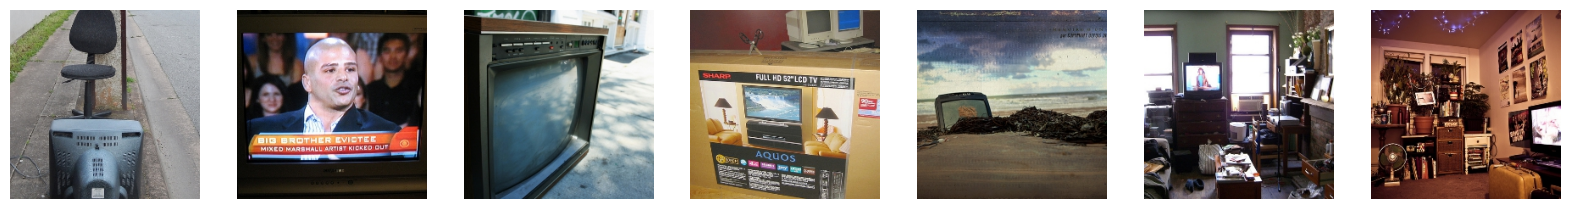

In [66]:
cluster = 514
test_indexes = np.where(kmeans_text_emb_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_10d.png')

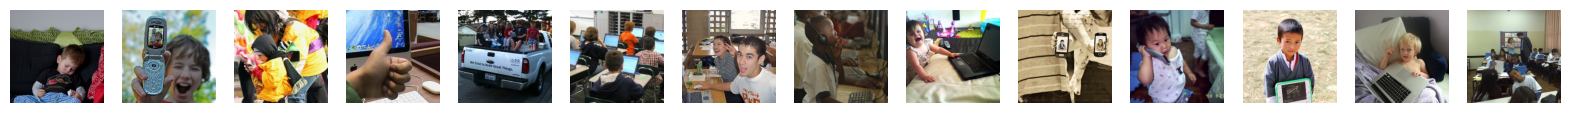

In [67]:
cluster = 259
test_indexes = np.where(kmeans_text_emb_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_10d.png')

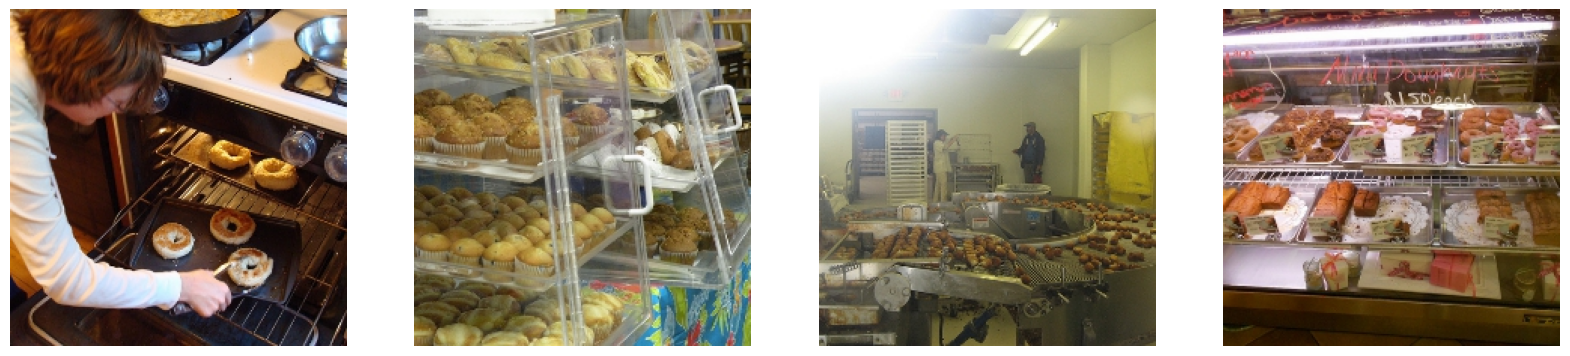

In [68]:
cluster = 693
test_indexes = np.where(kmeans_text_emb_10d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_10d.png')

###### 2D

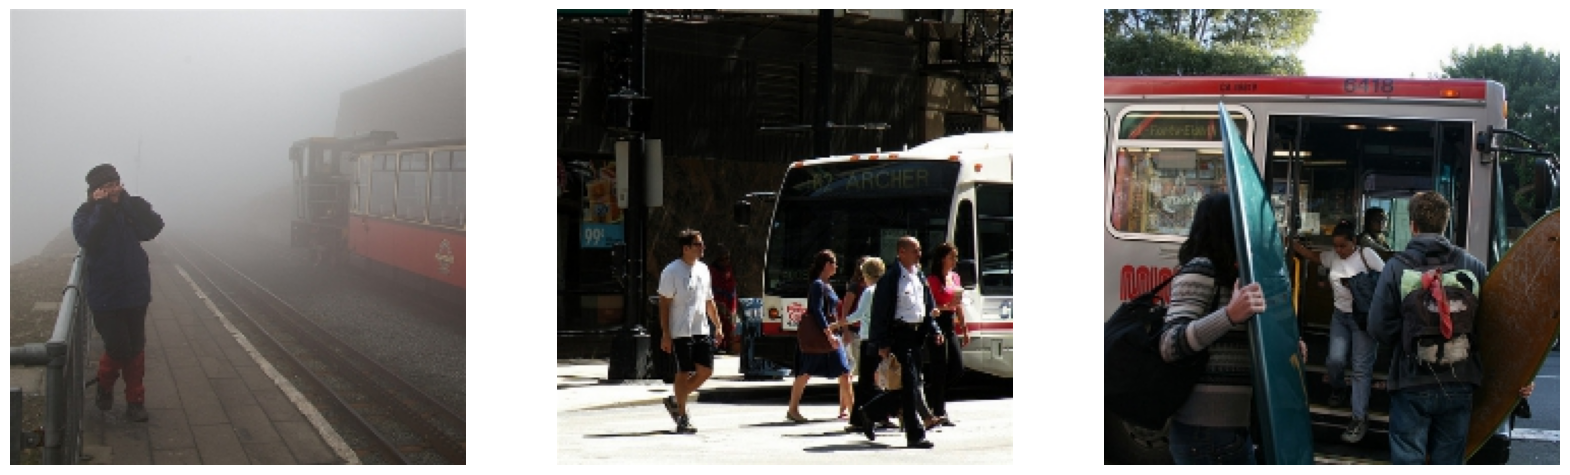

In [69]:
cluster = 25
test_indexes = np.where(kmeans_text_emb_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_2d.png')

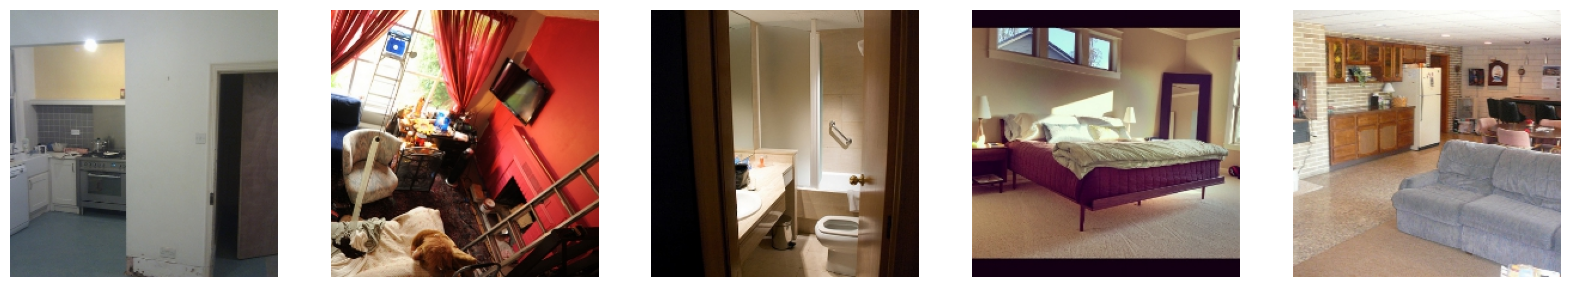

In [70]:
cluster = 100
test_indexes = np.where(kmeans_text_emb_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_2d.png')

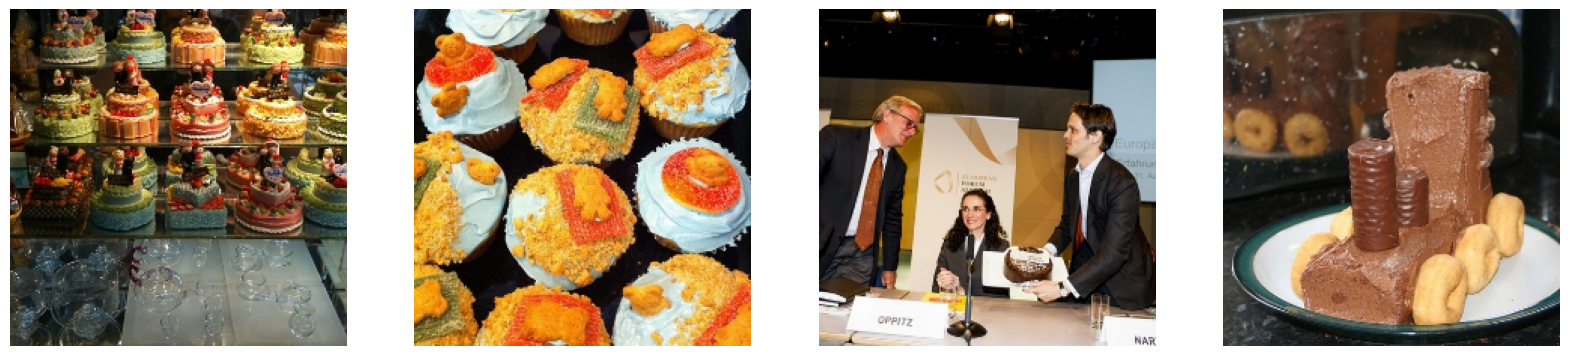

In [71]:
cluster = 514
test_indexes = np.where(kmeans_text_emb_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_2d.png')

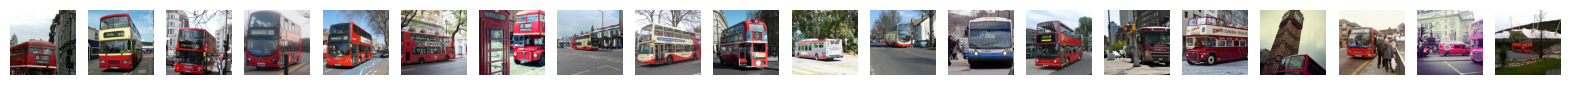

In [73]:
cluster = 74
test_indexes = np.where(kmeans_text_emb_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_2d.png')

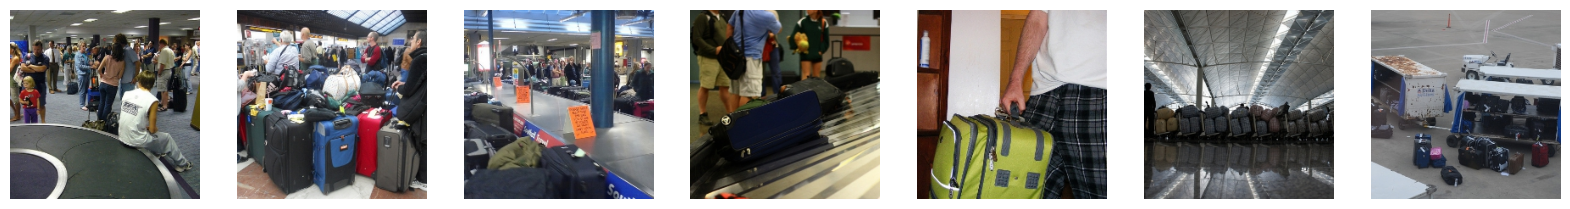

In [74]:
cluster = 426
test_indexes = np.where(kmeans_text_emb_2d.labels_ == cluster)[0]
test_images = torch.Tensor(train_images[test_indexes][:20]/255).permute(0, 2, 3, 1)

fig, axs = plt.subplots(1, len(test_images), figsize=(20, 10))

for i, ax in enumerate(axs):
    ax.axis('off')
    ax.imshow(test_images[i])
fig.savefig(f'text_emb_cluster({cluster})_samples_2d.png')

**Замечания:** \
Для латентного пространства не было целью избавления от коррелирующих признаков.

**Вывод:**
1. Выполнена кластеризация в 2D и 100D пространствах. Для обоих случаев оптимальное число кластеров находится в диапазоне от 750 до 1000;
2. Выбрано минимальное число кластеров, равное 750. Выбор сделан на основе графикоф метрик кластеризации (перегибы)
3. Проведена кластеризация в 2D и 10D. Облака точек были изображены на двумерном графике. Для 2D и 10D заметно расхождения в метках кластеров. Это связано с тем, что при уменьшении размерности теряется информация.
4. При проверке соответствия изображений в кластерах в 2D и 10D получены одинаково хорошие результаты.


### Проверка статистической связи

Проверка статистической связи между кластерами вокселей и caption embeddings с помощью таблицы сопряженности

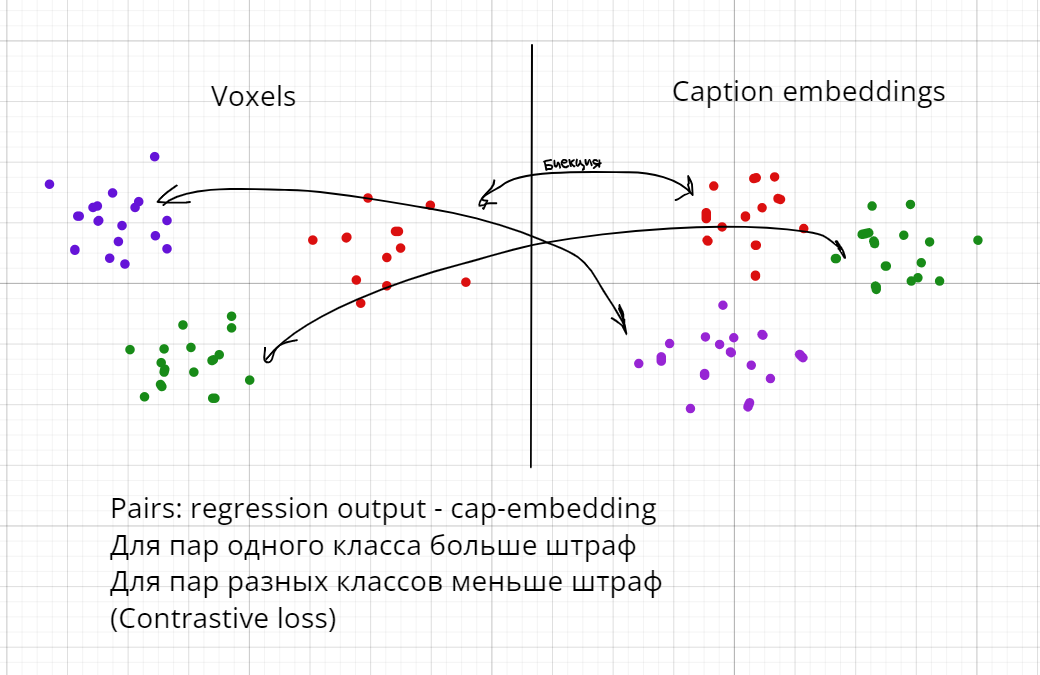

In [105]:
# уменьшение размерности до 10d
train_voxels_10d = UMAP(n_components=10, random_state=seed).fit_transform(train_voxels)

# кластеризация в 10d
kmeans_voxels = KMeans(n_clusters=1000, random_state=seed, n_init=3).fit(train_voxels_10d)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [118]:
# уменьшение размерности до 10d
train_caption_emb_10d = UMAP(n_components=10, random_state=seed).fit_transform(train_caption_emb)

# кластеризация в 10d
kmeans_text_emb = KMeans(n_clusters=1000, random_state=seed, n_init=3).fit(train_caption_emb_10d)

/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [119]:
alpha = 0.05
n = len(set(kmeans_voxels.labels_))
m = len(set(kmeans_text_emb.labels_))
imp_table = np.zeros((n, m))

In [120]:
for v_cluster, c_cluster in zip(kmeans_voxels.labels_, kmeans_text_emb.labels_):
    imp_table[v_cluster, c_cluster] += 1

In [121]:
from scipy.stats import chi2_contingency

chi2_contingency(imp_table, correction=True).statistic

1023546.6028045428

In [122]:
for v_cluster, c_cluster in zip(kmeans_voxels.labels_, kmeans_text_emb.labels_):
    if v_cluster == 2:
        print(v_cluster, c_cluster)

2 391
2 902
2 672
2 904
2 339
2 391
2 506
2 390
2 34
2 343
2 964


In [131]:
chi2_contingency(imp_table, correction=True).pvalue

3.4384693549912017e-72

$H0$: нет стат.связи, $p-value > alpha$ \
$H1$: есть стат.связь, $p-value < alpha$

Гипотеза была проверена методом таблицы сопряженности.$p-value < alpha$, следовательно, нулевая гипотеза отклоняется, между кластерами есть стат.связь, то есть можно предполагаеть о взаимооднозначном соответствии кластеров вокселей и кластеров текстовых описаний.

**ИТОГ АНАЛИЗА ДАННЫХ:** 
1. Высокая размерность пространства вокселей -> Больше требований к размеру обучающей выборки. \
Было обнаружено 45740 случаев наличия корреляция по Пирсону между вокселями. Для уменьшения размерности предпочтительно использовать PCA для отбора более информативных компонент. Однако, в этом нет необходимости в случае работы с сырыми данными.
2. Высокая размерность латентного представления captions -> Больше требований к размеру обучающей выборки.
Признаки латентного пространства менее коррелированы, поэтому уменьшение размерности может ухудшить данные.
3. Данные активности мозга плохо подаются кластеризации.\
    Причины:
    - Данные мозга трудно подаются кластеризации
    - Уменьшение размерности сильно влияет на качество кластеров
    - Плохо отобраны данные ROI
4. Была проверена гипотеза о наличии стат.связи кластеров вокселей и текстоых описаний. В результате, было подтверждено наличие статистической связи.

**Перспектива:** 
1. Уменьшение пространства вокселей -> уменьшение количества обучаемых параметров.
2. Кластеризация сырых данных вокселей.
2. Проверить, как guidance scale влияет на среднее и дисперсию в текстовых embeddings;
3. Использовать знаний кластеризации текстовых embeddings для contrastive loss.